# HomeWork -4
## Objective
 In this homework, you will design a python class that encapsulates common univariate/bivariate analysis tasks. You will practice object oriented programing (OOP) while applying descriptive statistics and visualization to summarize your data and explore the relationship between two variables. 
 
 - Use the example provided in the class activity and expand it. The initializer of the class should take data and print out its shape and column names. 
 - Additionally, your class should include at least 5 methods (function) to do either univariate or bivariate analysis of your choice. 
 - Provide markdowns or comments for each part of your code.  

  - Create an instance of your class using Penguin data and use it to analyze it.
  
  - For each analysis you perform, write 1-2 sentence before that function call that clearly state
    the question you are trying to answer with that analysis. For example: "In this analysis I want to see what is the average mass for each species." 

  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

class PenguinAnalyzer:
    def __init__(self, data):
        self.df = data
        print("--- Dataset Initialized ---")
        print(f"Shape: {self.df.shape}")
        print(f"Columns: {list(self.df.columns)}")
        print("---------------------------\n")

    # Method 1: Univariate- Histogram
    def plot_distribution(self,column):
        plt.figure(figsize=(8, 4))
        sns.histplot(self.df[column], kde=True, color='skyblue')
        plt.title(f'Distribution of {column}')
        plt.show()
        
    # Method 2: Univariate - Category Counts
    def count_categories(self, column):
        plt.figure(figsize=(8, 4))
        sns.countplot(x=column, data=self.df, palette='viridis', legend=False)
        plt.title(f'Count of {column}')
        plt.show()

    # Method 3: Bivariate - Scatter Plot
    def plot_scatter(self, x_col, y_col, hue_col=None):
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=self.df, x=x_col, y=y_col, hue=hue_col)
        plt.title(f'{y_col} vs {x_col}')
        plt.show()

    # Method 4: Bivariate - Boxplot
    def plot_boxplot(self, cat_col, num_col):
        plt.figure(figsize=(8, 5))
        sns.boxplot(x=cat_col, y=num_col, data=self.df)
        plt.title(f'{num_col} by {cat_col}')
        plt.show()

    # Method 5: Univariate - Summary Stats
    def get_stats(self, column):
        print(f"Summary Statistics for {column}:")
        return self.df[column].describe()

In [2]:
penguins = sns.load_dataset("penguins")

In [3]:
analyzer = PenguinAnalyzer(penguins)

--- Dataset Initialized ---
Shape: (344, 7)
Columns: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
---------------------------



In this analysis, I want to see how many penguins of each species were observed in the study.


/var/folders/5v/6g0xydlj23q75glnyrzb6nz00000gn/T/ipykernel_11229/3073207291.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=self.df, palette='viridis', legend=False)


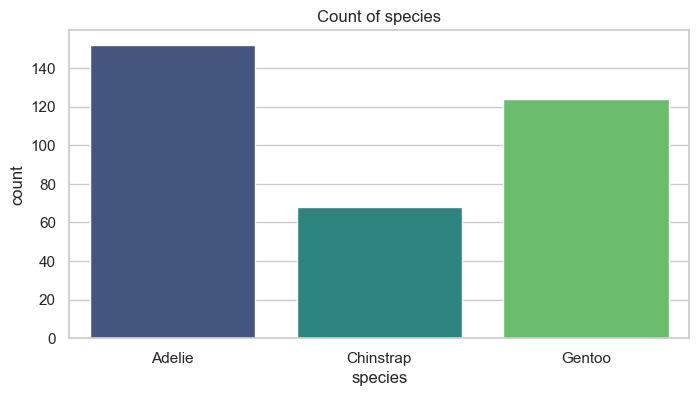

In [4]:
# ---Analysis 1 ---
print("In this analysis, I want to see how many penguins of each species were observed in the study.")
analyzer.count_categories('species')

I want to examine the distribution of body mass to see if there is a common weight range.


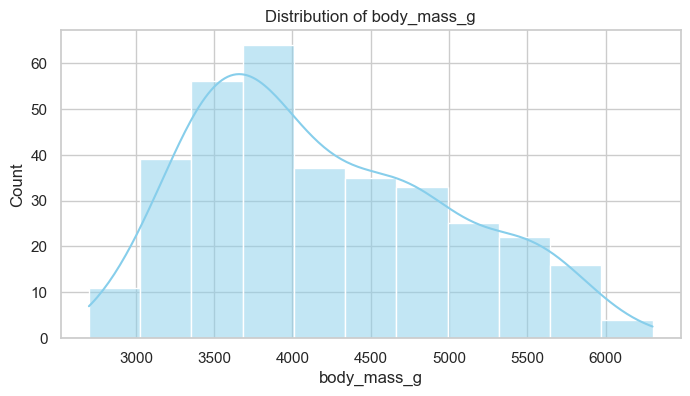

In [5]:
# --- Analysis 2 ---
print("I want to examine the distribution of body mass to see if there is a common weight range.")
analyzer.plot_distribution('body_mass_g')

I am interested in whether bill length and bill depth have a relationship, and if that differs by species.


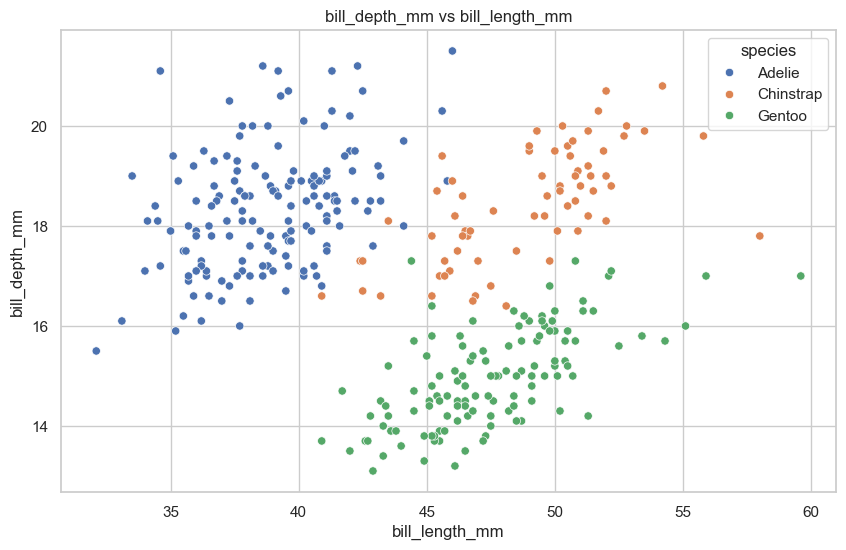

In [6]:
# ---Analysis 3 ---
print("I am interested in whether bill length and bill depth have a relationship, and if that differs by species.")
analyzer.plot_scatter('bill_length_mm', 'bill_depth_mm', hue_col='species')

I want to compare the flipper lengths across different islands to see if location impacts size.


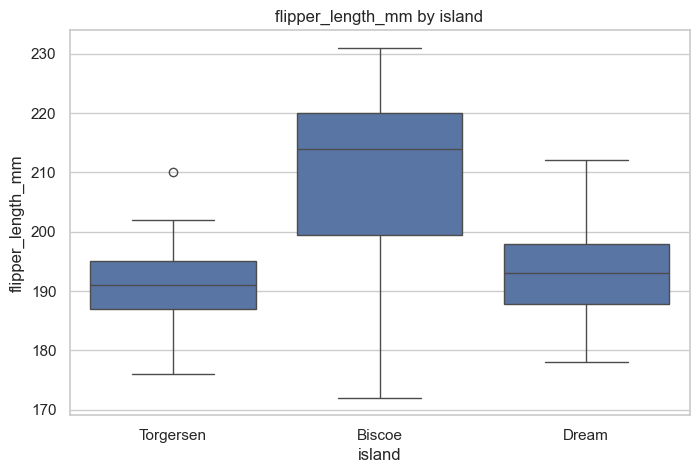

In [7]:
# --- Analysis 4 ---
print("I want to compare the flipper lengths across different islands to see if location impacts size.")
analyzer.plot_boxplot('island', 'flipper_length_mm')

In [8]:
# --- Analysis 5 ---
print("Finally, I want to see the specific numerical summary (mean, min,max) for flipper length.")
print(analyzer.get_stats('flipper_length_mm'))

Finally, I want to see the specific numerical summary (mean, min,max) for flipper length.
Summary Statistics for flipper_length_mm:
count    342.000000
mean     200.915205
std       14.061714
min      172.000000
25%      190.000000
50%      197.000000
75%      213.000000
max      231.000000
Name: flipper_length_mm, dtype: float64
